In [1]:
pip install shap


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import shap
import joblib
import pandas as pd

model = joblib.load("xgb_model.pkl")  # or cat_model / ensemble_model
scaler = joblib.load("scaler.pkl")


In [4]:
input_data = {
    'Header_Length': 100,
    'Protocol Type': 1,
    'Duration': 10000,
    'Rate': 999.0,
    'Srate': 900.0,
    'Drate': 850.0,
    'fin_flag_number': 1,
    'syn_flag_number': 1,
    'rst_flag_number': 1,
    'psh_flag_number': 1,
    'ack_flag_number': 1,
    'ece_flag_number': 1,
    'cwr_flag_number': 1,
    'ack_count': 5000,
    'syn_count': 4000,
    'fin_count': 3000,
    'rst_count': 2000,
    'HTTP': 1.0, 'HTTPS': 1.0, 'DNS': 0.0, 'Telnet': 1.0,
    'SMTP': 1.0, 'SSH': 1.0, 'IRC': 1.0, 'TCP': 1.0, 'UDP': 0.0,
    'DHCP': 0.0, 'ARP': 0.0, 'ICMP': 0.0, 'IGMP': 0.0, 'IPv': 1.0,
    'LLC': 0.0, 'Tot sum': 9999, 'Min': 1000, 'Max': 9999,
    'AVG': 9999, 'Std': 500, 'Tot size': 9999, 'IAT': 999,
    'Number': 9999, 'Magnitue': 1000, 'Radius': 1000,
    'Covariance': 999, 'Variance': 999, 'Weight': 999
}

df = pd.DataFrame([input_data])
X_scaled = scaler.transform(df)


In [5]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_scaled)


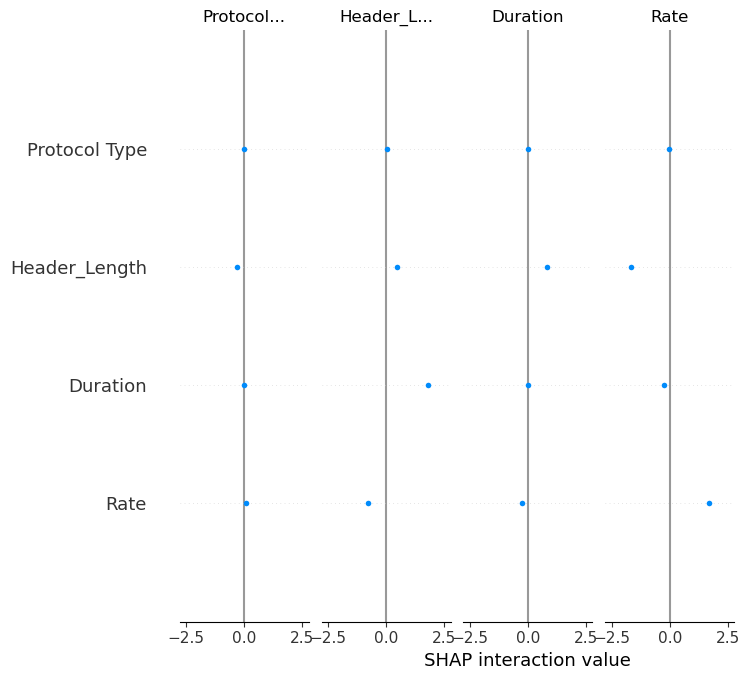

In [6]:
shap.summary_plot(shap_values, X_scaled, feature_names=df.columns)


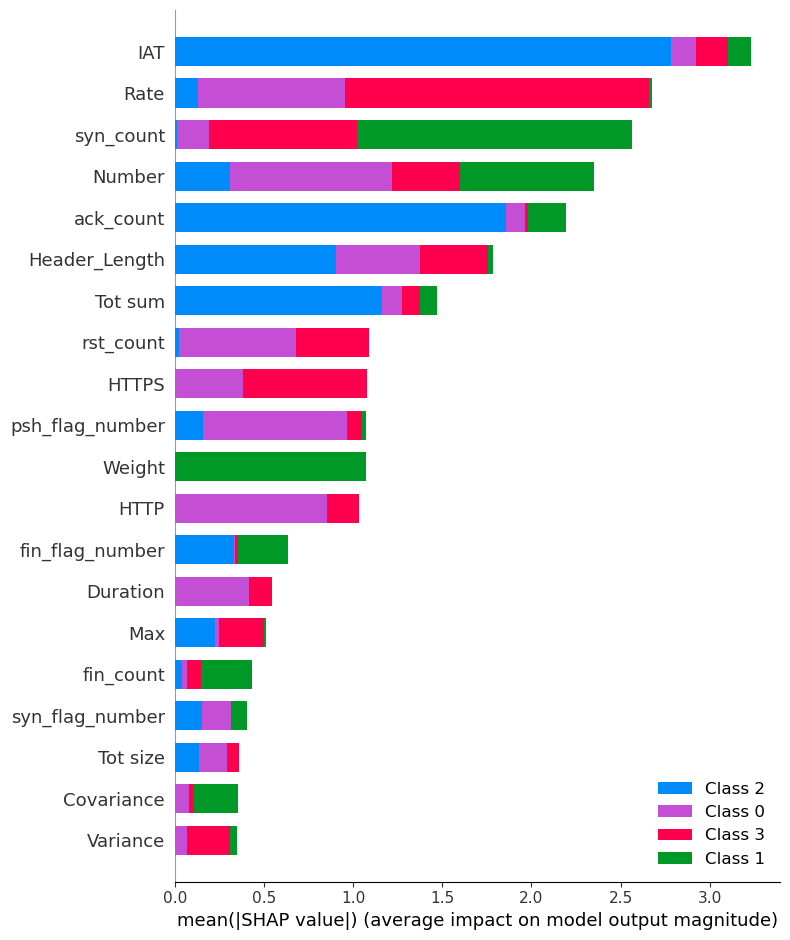

In [19]:
shap.summary_plot(shap_values, df, plot_type="bar")


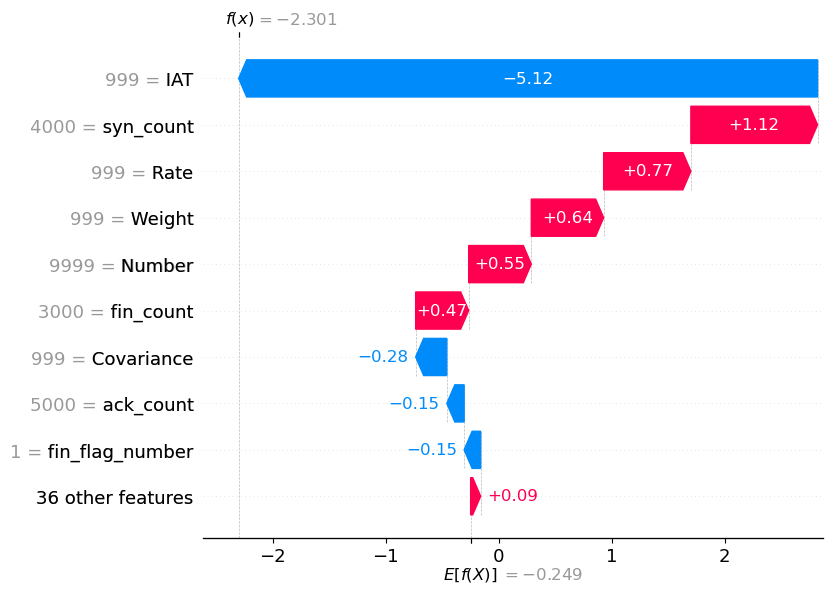

In [28]:
import shap
import numpy as np

sample_index = 0      # First sample
class_index = 1       # Class you're interested in (0 to 3 here)

# Extract just the SHAP values for that sample and class
single_shap_values = shap_values[sample_index, :, class_index]  # shape: (45,)

# Create a proper Explanation object
explanation = shap.Explanation(
    values=single_shap_values,
    base_values=explainer.expected_value[class_index],
    data=df.iloc[sample_index],
    feature_names=df.columns.tolist()
)

# Now plot
shap.plots.waterfall(explanation)


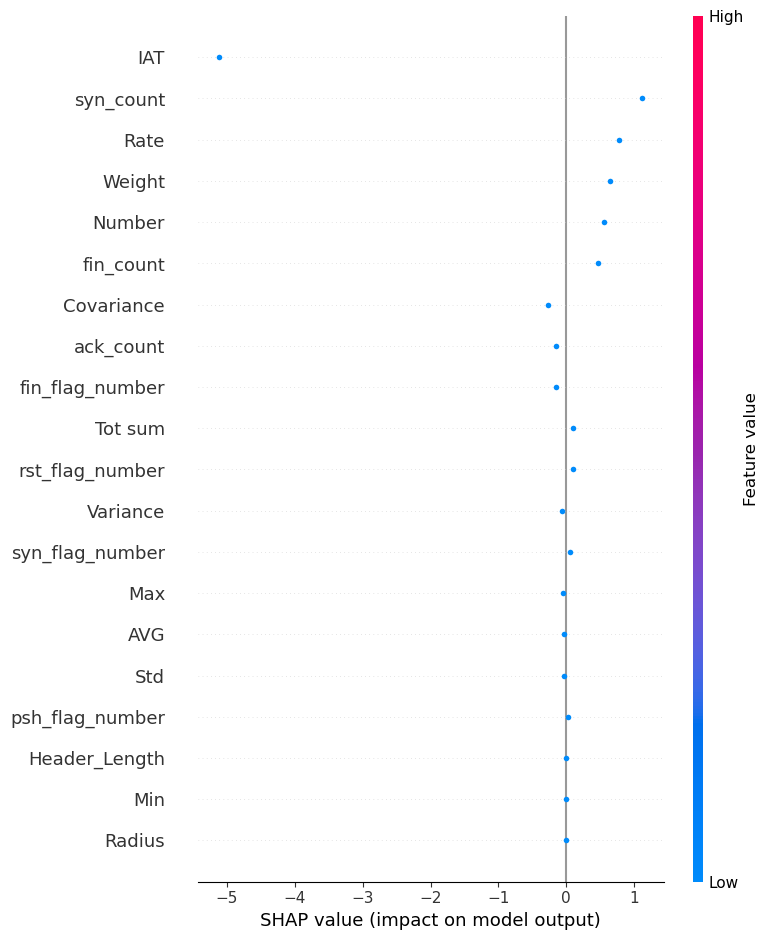

In [29]:
shap.summary_plot(shap_values[:, :, class_index], df)
